# Portfólio SQL: Engenharia Reversa, Normalização e Análise Histórica da Copa do Mundo
**Dataset Base:** [FIFA World Cup (Kaggle)](https://www.kaggle.com/datasets/abecklas/fifa-world-cup)

## 1. Introdução e Objetivo do Projeto
Este notebook apresenta o desenvolvimento completo do projeto final da disciplina de Banco de Dados. O objetivo principal é demonstrar a aplicação prática de conceitos de engenharia reversa, normalização de dados e análise exploratória/analítica através da linguagem SQL, utilizando o ecossistema do **SQLite**.

A partir dos dados brutos sobre a história das Copas do Mundo, foi proposta uma reestruturação lógica para eliminar redundâncias e, subsequentemente, a criação de 15 consultas originais e de alta complexidade analítica.

In [54]:
import kagglehub

# Download da versão mais recente do dataset via API
path = kagglehub.dataset_download("abecklas/fifa-world-cup")

print("Path dos arquivos do dataset:", path)

Using Colab cache for faster access to the 'fifa-world-cup' dataset.
Path dos arquivos do dataset: /kaggle/input/fifa-world-cup


In [55]:
import pandas as pd
import numpy as np


df_matches = pd.read_csv('/kaggle/input/fifa-world-cup/WorldCupMatches.csv').dropna(how='all')
df_players = pd.read_csv('/kaggle/input/fifa-world-cup/WorldCupPlayers.csv').dropna(how='all')
df_cups = pd.read_csv('/kaggle/input/fifa-world-cup/WorldCups.csv').dropna(how='all')

# Inspeção das colunas originais (Denormalizadas)
print("Colunas Matches:", df_matches.columns.tolist())
print("Colunas Players:", df_players.columns.tolist())
print("Colunas Cups:", df_cups.columns.tolist())

Colunas Matches: ['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name', 'Home Team Goals', 'Away Team Goals', 'Away Team Name', 'Win conditions', 'Attendance', 'Half-time Home Goals', 'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2', 'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials']
Colunas Players: ['RoundID', 'MatchID', 'Team Initials', 'Coach Name', 'Line-up', 'Shirt Number', 'Player Name', 'Position', 'Event']
Colunas Cups: ['Year', 'Country', 'Winner', 'Runners-Up', 'Third', 'Fourth', 'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance']


## 2. Processo de Engenharia Reversa e Normalização

### O Problema dos Dados Brutos (Denormalizados)
Ao inspecionar os arquivos originais extraídos do Kaggle, foi identificados os seguintes problemas de redundância e acoplamento de entidades:
* **Matches:** Mistura dados cronológicos da partida com informações estruturais do estádio (`Stadium`), da cidade (`City`), dos oficiais de arbitragem (`Referee`, `Assistant 1`, `Assistant 2`) e dados redundantes de seleções (`Home Team Name`, `Home Team Initials`, etc.)
* **Players:** Replica o nome do jogador (`Player Name`), sua camisa (`Shirt Number`) e o técnico (`Coach Name`) de forma puramente textual a cada nova partida (`MatchID`) que ele participa, gerando anomalias caso um nome precise ser atualizado
* **Cups:** Concentra o histórico de campeões e sedes de maneira textual, em vez de referenciar IDs únicos de federações

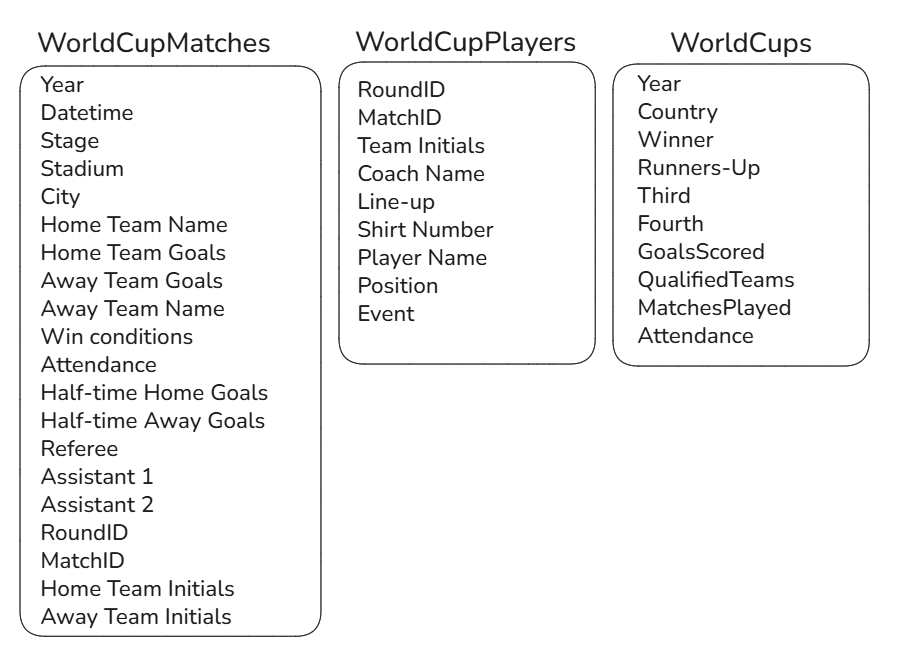

### Modelo Físico Proposto (Normalizado - 1FN, 2FN e 3FN)
Para eliminar essas redundâncias, as colunas foram atomizadas e distribuídas em tabelas lógicas interconectadas por chaves estrangeiras (`FOREIGN KEY`), garantindo a integridade referencial:

1. **TB_SELECAO:** Isolamento das federações (`ID_SELECAO`, `SIGLA_SELECAO`, `NOME_SELECAO`). Mapeado a partir de *Home/Away Team Names, Initials* e finalistas de *Cups*.
2. **TB_CIDADE:** Isolamento geográfico das sedes (`ID_CIDADE`, `NOME_CIDADE`). Mapeado de *Matches.City*.
3. **TB_ESTADIO:** Vinculação do estádio à sua cidade (`ID_ESTADIO`, `NOME_ESTADIO`, `ID_CIDADE`). Mapeado de *Matches.Stadium*.
4. **TB_ARBITRO:** Centralização de oficiais (`ID_ARBITRO`, `NOME_ARBITRO`, `PAIS_ORIGEM`). Mapeado de *Matches.Referee* e assistentes.
5. **TB_TECNICO:** Registro de treinadores (`ID_TECNICO`, `NOME_TECNICO`, `PAIS_ORIGEM`). Mapeado de *Players.Coach Name*.
6. **TB_COPA:** Estatísticas gerais por edição (`ANO_COPA`, `PAIS_SEDE`, `ID_CAMPEAO`, `ID_VICE`, `ID_TERCEIRO`, `ID_QUARTO`, `TOTAL_GOLS`, `TOTAL_TIMES`, `TOTAL_PARTIDAS`, `PUBLICO_TOTAL`).
7. **TB_PARTIDA:** Núcleo de eventos de jogos (`ID_PARTIDA`, `ANO_COPA`, `DATA_HORA`, `FASE`, `ID_ESTADIO`, `ID_SELECAO_HOME`, `ID_SELECAO_AWAY`, `GOLS_HOME`, `GOLS_AWAY`, `GOLS_HT_HOME`, `GOLS_HT_AWAY`, `CONDICOES_VITORIA`, `PUBLICO`, `ROUND_ID`, `ID_ARBITRO`, `ID_ASSISTENTE_1`, `ID_ASSISTENTE_2`, `ID_TECNICO_HOME`, `ID_TECNICO_AWAY`).
8. **TB_JOGADOR:** Catálogo único de atletas (`ID_JOGADOR`, `NOME_JOGADOR`). Mapeado de *Players.Player Name*.
9. **TB_PARTIDA_JOGADOR:** Tabela associativa que liga atletas e seleções às suas respectivas partidas (`ID_PARTIDA`, `ID_JOGADOR`, `ID_SELECAO`, `NUMERO_CAMISA`, `ESCALACAO_INICIAL`, `POSICAO`).
10. **TB_EVENTO_JOGADOR:** Entidade armazena os eventos cronológicos de jogo (`ID_EVENTO`, `ID_PARTIDA`, `ID_JOGADOR`, `TIPO_EVENTO`, `MINUTO`).

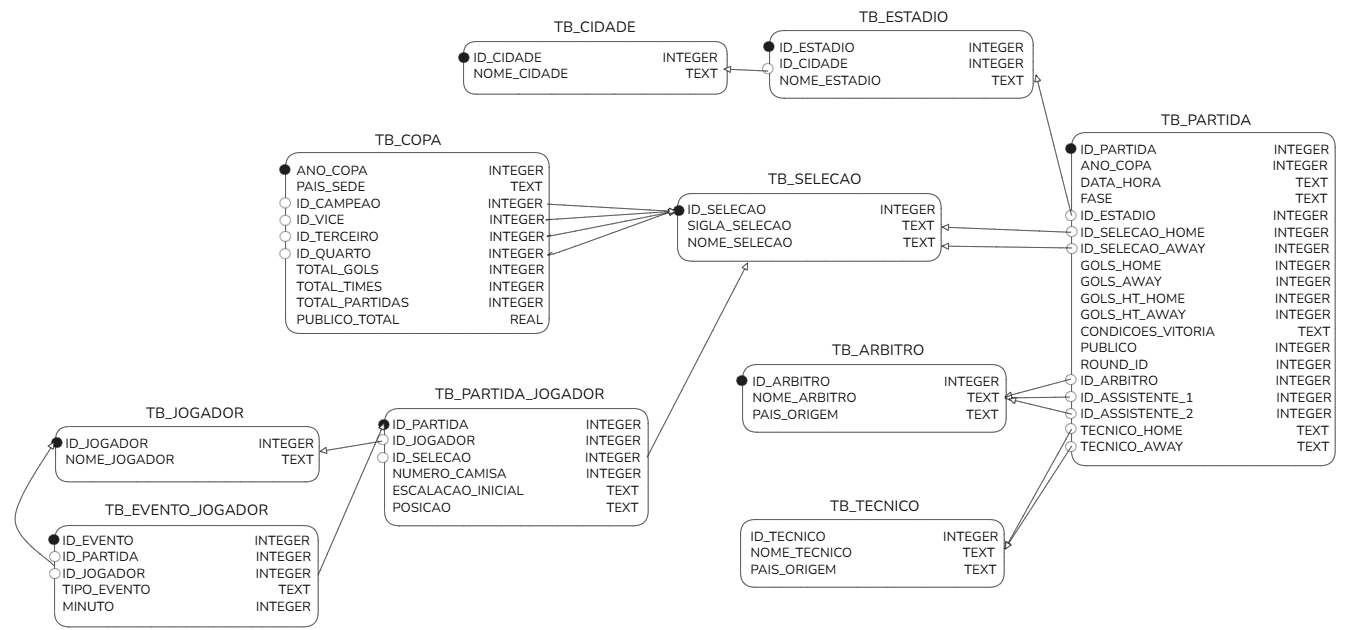

## 3. Preparação do Ambiente Relacional e Criação das Tabelas

Instalação da extensão necessária para rodar consultas SQL em modo nativo diretamente no notebook (`%sql`), inicialização da conexão com o banco de dados via SQLite3 e ativação do suporte de Integridade Referencial.

In [56]:
# instala extensão SQL para jupyter notebook
!pip install ipython-sql -q

import sqlite3

# cria/conecta ao arquivo do Banco de Dados
conexao = sqlite3.connect('copa_do_mundo.db')
cursor = conexao.cursor()

# verificação de chaves estrangeiras (FOREIGN KEY)
cursor.execute("PRAGMA foreign_keys = ON;")

# ativa comandos SQL
%load_ext sql
%config SqlMagic.style = 'plain'
%sql sqlite:///copa_do_mundo.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


### Script de Definição de Dados (DDL)
Abaixo, definimos explicitamente as tabelas lógicas, aplicando tipos de dados consistentes (`INTEGER`, `TEXT`, `REAL`), chaves primárias automáticas e as respectivas restrições referenciais

In [57]:
tabelas = [
    """
    CREATE TABLE IF NOT EXISTS TB_SELECAO (
        ID_SELECAO INTEGER PRIMARY KEY AUTOINCREMENT,
        SIGLA_SELECAO TEXT NOT NULL,
        NOME_SELECAO TEXT NOT NULL UNIQUE
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_CIDADE (
        ID_CIDADE INTEGER PRIMARY KEY AUTOINCREMENT,
        NOME_CIDADE TEXT NOT NULL UNIQUE
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_ESTADIO (
        ID_ESTADIO INTEGER PRIMARY KEY AUTOINCREMENT,
        NOME_ESTADIO TEXT NOT NULL,
        ID_CIDADE INTEGER NOT NULL,
        FOREIGN KEY (ID_CIDADE) REFERENCES TB_CIDADE (ID_CIDADE)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_ARBITRO (
        ID_ARBITRO INTEGER PRIMARY KEY AUTOINCREMENT,
        NOME_ARBITRO TEXT NOT NULL UNIQUE,
        PAIS_ORIGEM TEXT
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_TECNICO (
        ID_TECNICO INTEGER PRIMARY KEY AUTOINCREMENT,
        NOME_TECNICO TEXT NOT NULL,
        PAIS_ORIGEM TEXT,
        UNIQUE(NOME_TECNICO, PAIS_ORIGEM)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_COPA (
        ANO_COPA INTEGER PRIMARY KEY,
        PAIS_SEDE TEXT NOT NULL,
        ID_CAMPEAO INTEGER NOT NULL,
        ID_VICE INTEGER NOT NULL,
        ID_TERCEIRO INTEGER NOT NULL,
        ID_QUARTO INTEGER NOT NULL,
        TOTAL_GOLS INTEGER NOT NULL,
        TOTAL_TIMES INTEGER NOT NULL,
        TOTAL_PARTIDAS INTEGER NOT NULL,
        PUBLICO_TOTAL REAL,
        FOREIGN KEY (ID_CAMPEAO) REFERENCES TB_SELECAO (ID_SELECAO),
        FOREIGN KEY (ID_VICE) REFERENCES TB_SELECAO (ID_SELECAO),
        FOREIGN KEY (ID_TERCEIRO) REFERENCES TB_SELECAO (ID_SELECAO),
        FOREIGN KEY (ID_QUARTO) REFERENCES TB_SELECAO (ID_SELECAO)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_PARTIDA (
        ID_PARTIDA INTEGER PRIMARY KEY,
        ANO_COPA INTEGER NOT NULL,
        DATA_HORA TEXT NOT NULL,
        FASE TEXT NOT NULL,
        ID_ESTADIO INTEGER NOT NULL,
        ID_SELECAO_HOME INTEGER NOT NULL,
        ID_SELECAO_AWAY INTEGER NOT NULL,
        GOLS_HOME INTEGER NOT NULL,
        GOLS_AWAY INTEGER NOT NULL,
        GOLS_HT_HOME INTEGER,
        GOLS_HT_AWAY INTEGER,
        CONDICOES_VITORIA TEXT,
        PUBLICO INTEGER,
        ROUND_ID INTEGER NOT NULL,
        ID_ARBITRO INTEGER,
        ID_ASSISTENTE_1 INTEGER,
        ID_ASSISTENTE_2 INTEGER,
        ID_TECNICO_HOME INTEGER NOT NULL,
        ID_TECNICO_AWAY INTEGER NOT NULL,
        FOREIGN KEY (ANO_COPA) REFERENCES TB_COPA (ANO_COPA),
        FOREIGN KEY (ID_ESTADIO) REFERENCES TB_ESTADIO (ID_ESTADIO),
        FOREIGN KEY (ID_SELECAO_HOME) REFERENCES TB_SELECAO (ID_SELECAO),
        FOREIGN KEY (ID_SELECAO_AWAY) REFERENCES TB_SELECAO (ID_SELECAO),
        FOREIGN KEY (ID_ARBITRO) REFERENCES TB_ARBITRO (ID_ARBITRO),
        FOREIGN KEY (ID_ASSISTENTE_1) REFERENCES TB_ARBITRO (ID_ARBITRO),
        FOREIGN KEY (ID_ASSISTENTE_2) REFERENCES TB_ARBITRO (ID_ARBITRO),
        FOREIGN KEY (ID_TECNICO_HOME) REFERENCES TB_TECNICO (ID_TECNICO),
        FOREIGN KEY (ID_TECNICO_AWAY) REFERENCES TB_TECNICO (ID_TECNICO)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_JOGADOR (
        ID_JOGADOR INTEGER PRIMARY KEY,
        NOME_JOGADOR TEXT NOT NULL
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_PARTIDA_JOGADOR (
        ID_PARTIDA INTEGER NOT NULL,
        ID_JOGADOR INTEGER NOT NULL,
        ID_SELECAO INTEGER NOT NULL,
        NUMERO_CAMISA INTEGER NOT NULL,
        ESCALACAO_INICIAL TEXT NOT NULL,
        POSICAO TEXT,
        PRIMARY KEY (ID_PARTIDA, ID_JOGADOR),
        FOREIGN KEY (ID_PARTIDA) REFERENCES TB_PARTIDA (ID_PARTIDA),
        FOREIGN KEY (ID_JOGADOR) REFERENCES TB_JOGADOR (ID_JOGADOR),
        FOREIGN KEY (ID_SELECAO) REFERENCES TB_SELECAO (ID_SELECAO)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS TB_EVENTO_JOGADOR (
        ID_EVENTO INTEGER PRIMARY KEY AUTOINCREMENT,
        ID_PARTIDA INTEGER NOT NULL,
        ID_JOGADOR INTEGER NOT NULL,
        TIPO_EVENTO TEXT NOT NULL,
        MINUTO INTEGER NOT NULL,
        FOREIGN KEY (ID_PARTIDA, ID_JOGADOR) REFERENCES TB_PARTIDA_JOGADOR (ID_PARTIDA, ID_JOGADOR)
    );
    """
]

for tabela in tabelas:
    cursor.execute(tabela)

conexao.commit()

## 4. Processamento de Dados (ETL) e População do Banco

Este bloco extrai os valores textuais dos DataFrames brutos (`df_matches`, `df_players`, `df_cups`), limpa espaços em branco excessivos, trata strings vazias e mapeia os relacionamentos de chaves estrangeiras

A inserção é feita de maneira incremental e segura, garantindo que restrições exclusivas (`UNIQUE` e `PRIMARY KEY`) não sejam violadas caso o notebook seja reexecutado

In [36]:
import re

for df_temp in [df_matches, df_players, df_cups]:
    for col in df_temp.select_dtypes(include=['object']).columns:
        df_temp[col] = df_temp[col].astype(str).str.strip()


df_matches = df_matches.replace(r'^\s*$', np.nan, regex=True)
df_players = df_players.replace(r'^\s*$', np.nan, regex=True)
df_cups = df_cups.replace(r'^\s*$', np.nan, regex=True)

# POPULA TB_SELECAO
todas_selecoes = pd.concat([
    df_matches['Home Team Name'], df_matches['Away Team Name'],
    df_cups['Winner'], df_cups['Runners-Up'], df_cups['Third'], df_cups['Fourth']
]).dropna().unique()

df_selecao_final = pd.DataFrame({'NOME_SELECAO': todas_selecoes})
siglas_home = df_matches[['Home Team Name', 'Home Team Initials']].drop_duplicates().rename(columns={'Home Team Name':'NOME_SELECAO', 'Home Team Initials':'SIGLA_SELECAO'})
siglas_away = df_matches[['Away Team Name', 'Away Team Initials']].drop_duplicates().rename(columns={'Away Team Name':'NOME_SELECAO', 'Away Team Initials':'SIGLA_SELECAO'})
df_siglas = pd.concat([siglas_home, siglas_away]).drop_duplicates(subset=['NOME_SELECAO'])

df_selecao_final = df_selecao_final.merge(df_siglas, on='NOME_SELECAO', how='left')
df_selecao_final['SIGLA_SELECAO'] = df_selecao_final['SIGLA_SELECAO'].fillna('XXX')


existing_selecoes_db = pd.read_sql("SELECT NOME_SELECAO FROM TB_SELECAO", conexao)
selecoes_a_inserir = df_selecao_final[~df_selecao_final['NOME_SELECAO'].isin(existing_selecoes_db['NOME_SELECAO'])]

if not selecoes_a_inserir.empty:
    selecoes_a_inserir.to_sql('TB_SELECAO', conexao, if_exists='append', index=False)

dict_selecao = pd.read_sql("SELECT ID_SELECAO, NOME_SELECAO FROM TB_SELECAO", conexao).set_index('NOME_SELECAO')['ID_SELECAO'].to_dict()

# POPULA TB_CIDADE
cidades_unicas = df_matches['City'].dropna().unique()
df_cidade_final = pd.DataFrame({'NOME_CIDADE': cidades_unicas})
existing_cidades_db = pd.read_sql("SELECT NOME_CIDADE FROM TB_CIDADE", conexao)
cidades_a_inserir = df_cidade_final[~df_cidade_final['NOME_CIDADE'].isin(existing_cidades_db['NOME_CIDADE'])]

if not cidades_a_inserir.empty:
    cidades_a_inserir.to_sql('TB_CIDADE', conexao, if_exists='append', index=False)
dict_cidade = pd.read_sql("SELECT ID_CIDADE, NOME_CIDADE FROM TB_CIDADE", conexao).set_index('NOME_CIDADE')['ID_CIDADE'].to_dict()

# POPULA TB_ESTADIO
df_estadio_bruto = df_matches[['Stadium', 'City']].dropna().drop_duplicates()
df_estadio_bruto['ID_CIDADE'] = df_estadio_bruto['City'].map(dict_cidade)
df_estadio_final = df_estadio_bruto[['Stadium', 'ID_CIDADE']].rename(columns={'Stadium': 'NOME_ESTADIO'})

existing_estadios_db = pd.read_sql("SELECT NOME_ESTADIO, ID_CIDADE FROM TB_ESTADIO", conexao)
existing_estadios_tuples = set(tuple(row) for row in existing_estadios_db[['NOME_ESTADIO', 'ID_CIDADE']].to_numpy())

df_estadio_final['estadio_cidade_tuple'] = list(zip(df_estadio_final['NOME_ESTADIO'], df_estadio_final['ID_CIDADE']))
estadios_a_inserir = df_estadio_final[~df_estadio_final['estadio_cidade_tuple'].isin(existing_estadios_tuples)].drop(columns=['estadio_cidade_tuple'])

if not estadios_a_inserir.empty:
    estadios_a_inserir.to_sql('TB_ESTADIO', conexao, if_exists='append', index=False)
dict_estadio = pd.read_sql("SELECT ID_ESTADIO, NOME_ESTADIO FROM TB_ESTADIO", conexao).set_index('NOME_ESTADIO')['ID_ESTADIO'].to_dict()

# POPULA TB_ARBITRO
todos_arbitros = pd.concat([df_matches['Referee'], df_matches['Assistant 1'], df_matches['Assistant 2']]).dropna().unique()
df_arbitro_final = pd.DataFrame({'NOME_ARBITRO': todos_arbitros})
df_arbitro_final['NOME_ARBITRO_RAW'] = df_arbitro_final['NOME_ARBITRO']
df_arbitro_final['PAIS_ORIGEM'] = df_arbitro_final['NOME_ARBITRO'].str.extract(r'\((.*?)\)')
df_arbitro_final['NOME_ARBITRO'] = df_arbitro_final['NOME_ARBITRO'].str.replace(r'\s*\([A-Za-z]{2,3}\)\s*$', '', regex=True).str.strip()

# No need for existing_arbitros_db check here, as we are dropping and recreating TB_ARBITRO.
df_arbitro_final[['NOME_ARBITRO', 'PAIS_ORIGEM']].to_sql('TB_ARBITRO', conexao, if_exists='append', index=False)
dict_arbitro = pd.read_sql("SELECT ID_ARBITRO, NOME_ARBITRO FROM TB_ARBITRO", conexao).set_index('NOME_ARBITRO')['ID_ARBITRO'].to_dict()

# POPULAR TB_TECNICO
all_coach_names_raw = df_players['Coach Name'].dropna().unique()

df_tecnico_final = pd.DataFrame({'NOME_TECNICO_RAW': all_coach_names_raw})
df_tecnico_final['PAIS_ORIGEM'] = df_tecnico_final['NOME_TECNICO_RAW'].str.extract(r'\((.*?)\)')
df_tecnico_final['NOME_TECNICO'] = df_tecnico_final['NOME_TECNICO_RAW'].str.replace(r'\s*\([A-Za-z]{2,3}\)\s*$', '', regex=True).str.strip()

# No need for existing_tecnicos_db check here, as we are dropping and recreating TB_TECNICO.
df_tecnico_final[['NOME_TECNICO', 'PAIS_ORIGEM']].to_sql('TB_TECNICO', conexao, if_exists='append', index=False)

dict_tecnico = pd.read_sql("SELECT ID_TECNICO, NOME_TECNICO, PAIS_ORIGEM FROM TB_TECNICO", conexao)
dict_tecnico['TECNICO_COMPLETO'] = dict_tecnico['NOME_TECNICO'] + ' (' + dict_tecnico['PAIS_ORIGEM'].fillna('') + ')'
dict_tecnico = dict_tecnico.set_index('TECNICO_COMPLETO')['ID_TECNICO'].to_dict()

# POPULA TB_COPA
df_copa_final = pd.DataFrame({
    'ANO_COPA': df_cups['Year'].astype(int),
    'PAIS_SEDE': df_cups['Country'],
    'ID_CAMPEAO': df_cups['Winner'].map(dict_selecao),
    'ID_VICE': df_cups['Runners-Up'].map(dict_selecao),
    'ID_TERCEIRO': df_cups['Third'].map(dict_selecao),
    'ID_QUARTO': df_cups['Fourth'].map(dict_selecao),
    'TOTAL_GOLS': df_cups['GoalsScored'].astype(int),
    'TOTAL_TIMES': df_cups['QualifiedTeams'].astype(int),
    'TOTAL_PARTIDAS': df_cups['MatchesPlayed'].astype(int),
    'PUBLICO_TOTAL': df_cups['Attendance'].astype(str).str.replace('.', '', regex=False).astype(float)
})

existing_copa_db = pd.read_sql("SELECT ANO_COPA FROM TB_COPA", conexao)
copas_a_inserir = df_copa_final[~df_copa_final['ANO_COPA'].isin(existing_copa_db['ANO_COPA'])]

if not copas_a_inserir.empty:
    copas_a_inserir.to_sql('TB_COPA', conexao, if_exists='append', index=False)

# Clean referee names in df_matches before mapping to dict_arbitro
df_matches['Referee_cleaned'] = df_matches['Referee'].str.replace(r'\s*\([A-Za-z]{2,3}\)\s*$', '', regex=True).str.strip()
df_matches['Assistant 1_cleaned'] = df_matches['Assistant 1'].str.replace(r'\s*\([A-Za-z]{2,3}\)\s*$', '', regex=True).str.strip()
df_matches['Assistant 2_cleaned'] = df_matches['Assistant 2'].str.replace(r'\s*\([A-Za-z]{2,3}\)\s*$', '', regex=True).str.strip()

# POPULA TB_PARTIDA
dict_tecnicos_match_initials = df_players.dropna(subset=['Coach Name']).drop_duplicates(subset=['MatchID', 'Team Initials']).set_index(['MatchID', 'Team Initials'])['Coach Name'].to_dict()

df_partida_final = pd.DataFrame()
df_partida_final['ID_PARTIDA'] = df_matches['MatchID'].astype(int)
df_partida_final['ANO_COPA'] = df_matches['Year'].astype(int)
df_partida_final['DATA_HORA'] = df_matches['Datetime']
df_partida_final['FASE'] = df_matches['Stage']
df_partida_final['ID_ESTADIO'] = df_matches['Stadium'].map(dict_estadio)
df_partida_final['ID_SELECAO_HOME'] = df_matches['Home Team Name'].map(dict_selecao)
df_partida_final['ID_SELECAO_AWAY'] = df_matches['Away Team Name'].map(dict_selecao)
df_partida_final['GOLS_HOME'] = df_matches['Home Team Goals'].fillna(0).astype(int)
df_partida_final['GOLS_AWAY'] = df_matches['Away Team Goals'].fillna(0).astype(int)
df_partida_final['GOLS_HT_HOME'] = pd.to_numeric(df_matches['Half-time Home Goals']).astype('Int64')
df_partida_final['GOLS_HT_AWAY'] = pd.to_numeric(df_matches['Half-time Away Goals']).astype('Int64')
df_partida_final['CONDICOES_VITORIA'] = df_matches['Win conditions']
df_partida_final['PUBLICO'] = pd.to_numeric(df_matches['Attendance']).astype('Int64')
df_partida_final['ROUND_ID'] = df_matches['RoundID'].astype(int)
df_partida_final['ID_ARBITRO'] = df_matches['Referee_cleaned'].map(dict_arbitro)
df_partida_final['ID_ASSISTENTE_1'] = df_matches['Assistant 1_cleaned'].map(dict_arbitro)
df_partida_final['ID_ASSISTENTE_2'] = df_matches['Assistant 2_cleaned'].map(dict_arbitro)

df_partida_final['TECNICO_HOME_NOME'] = df_matches.apply(lambda row: dict_tecnicos_match_initials.get((row['MatchID'], row['Home Team Initials']), None), axis=1)
df_partida_final['TECNICO_AWAY_NOME'] = df_matches.apply(lambda row: dict_tecnicos_match_initials.get((row['MatchID'], row['Away Team Initials']), None), axis=1)

df_partida_final['ID_TECNICO_HOME'] = df_partida_final['TECNICO_HOME_NOME'].map(dict_tecnico).fillna(0).astype(int)
df_partida_final['ID_TECNICO_AWAY'] = df_partida_final['TECNICO_AWAY_NOME'].map(dict_tecnico).fillna(0).astype(int)

df_partida_final = df_partida_final.drop(columns=['TECNICO_HOME_NOME', 'TECNICO_AWAY_NOME'])
df_partida_final = df_partida_final.drop_duplicates(subset=['ID_PARTIDA'])

# No need for existing_partida_db check here, as we are dropping and recreating TB_PARTIDA.
df_partida_final.to_sql('TB_PARTIDA', conexao, if_exists='append', index=False)

# POPULA TB_JOGADOR
df_jogador_unico = df_players[['Player Name']].dropna().drop_duplicates(subset=['Player Name'])
df_jogador_final = df_jogador_unico.rename(columns={'Player Name': 'NOME_JOGADOR'})

existing_jogador_db = pd.read_sql("SELECT NOME_JOGADOR FROM TB_JOGADOR", conexao)
jogadores_a_inserir = df_jogador_final[~df_jogador_final['NOME_JOGADOR'].isin(existing_jogador_db['NOME_JOGADOR'])]

if not jogadores_a_inserir.empty:
    jogadores_a_inserir.to_sql('TB_JOGADOR', conexao, if_exists='append', index=False)

dict_jogador = pd.read_sql("SELECT ID_JOGADOR, NOME_JOGADOR FROM TB_JOGADOR", conexao).set_index('NOME_JOGADOR')['ID_JOGADOR'].to_dict()

# POPULA TB_PARTIDA_JOGADOR
valid_matches = set(df_partida_final['ID_PARTIDA'])
df_pj_bruto = df_players[df_players['MatchID'].isin(valid_matches)].copy()
df_pj_bruto['ID_JOGADOR'] = df_pj_bruto['Player Name'].map(dict_jogador)
df_pj_bruto.dropna(subset=['ID_JOGADOR'], inplace=True)
df_pj_bruto['ID_JOGADOR'] = df_pj_bruto['ID_JOGADOR'].astype(int)

sigla_to_nome_mapping_df = df_siglas[['NOME_SELECAO', 'SIGLA_SELECAO']].copy()
sigla_to_nome_mapping_df['SIGLA_SELECAO'] = sigla_to_nome_mapping_df['SIGLA_SELECAO'].astype(str).str.strip()
sigla_to_nome_mapping_df = sigla_to_nome_mapping_df.dropna(subset=['SIGLA_SELECAO'])
sigla_to_nome_mapping_df = sigla_to_nome_mapping_df.drop_duplicates(subset=['SIGLA_SELECAO'], keep='first')
sigla_to_nome_series = sigla_to_nome_mapping_df.set_index('SIGLA_SELECAO')['NOME_SELECAO']

df_pj_bruto['NOME_SELECAO_TEMPORARY'] = df_pj_bruto['Team Initials'].map(sigla_to_nome_series)
df_pj_bruto['ID_SELECAO'] = df_pj_bruto['NOME_SELECAO_TEMPORARY'].map(dict_selecao)
df_pj_bruto['ID_SELECAO'] = df_pj_bruto['ID_SELECAO'].ffill().fillna(1).astype(int) # Changed from fillna(method='bfill')
df_pj_bruto.drop(columns=['NOME_SELECAO_TEMPORARY'], inplace=True)

df_pj_final = pd.DataFrame({
    'ID_PARTIDA': df_pj_bruto['MatchID'].astype(int),
    'ID_JOGADOR': df_pj_bruto['ID_JOGADOR'].astype(int),
    'ID_SELECAO': df_pj_bruto['ID_SELECAO'],
    'NUMERO_CAMISA': df_pj_bruto['Shirt Number'].fillna(0).astype(int),
    'ESCALACAO_INICIAL': df_pj_bruto['Line-up'].apply(lambda x: 'S' if x == 'S' else 'N'),
    'POSICAO': df_pj_bruto['Position']
}).drop_duplicates(subset=['ID_PARTIDA', 'ID_JOGADOR'])

# No need for existing_pj_db check here, as we are dropping and recreating TB_PARTIDA_JOGADOR.
df_pj_final.to_sql('TB_PARTIDA_JOGADOR', conexao, if_exists='append', index=False)

# POPULA TB_EVENTO_JOGADOR
df_eventos_bruto = df_pj_bruto[['MatchID', 'ID_JOGADOR', 'Event']].dropna()
lista_eventos = []

for _, row in df_eventos_bruto.iterrows():
    eventos_encontrados = re.findall(r"([A-Za-z]+)(\d+)'", str(row['Event']))
    for tipo, minuto in eventos_encontrados:
        lista_eventos.append({
            'ID_PARTIDA': int(row['MatchID']),
            'ID_JOGADOR': int(row['ID_JOGADOR']),
            'TIPO_EVENTO': tipo,
            'MINUTO': int(minuto)
        })

if lista_eventos:
    df_eventos_final = pd.DataFrame(lista_eventos)
    df_eventos_final.to_sql('TB_EVENTO_JOGADOR', conexao, if_exists='append', index=False)

conexao.commit()
conexao.close()


conexao = sqlite3.connect('copa_do_mundo.db')

## 5. Dossiê das 15 Consultas Analíticas (Critério de Inovação)

A seguir, as 15 consultas estruturadas para extrair inteligência analítica e responder a perguntas complexas sobre o histórico das Copas do Mundo

Cada bloco é composto por:
1. A **Pergunta de Negócio** norteadora
2. A **Justificativa de Inovação**, detalhando a quebra de padrões óbvios da análise
3. A **Célula de Código** para execução direta no banco relacional conectado

### Consulta 1: Performance Ofensiva por Nacionalidade do Comando Técnico
* **Pergunta de Negócio:** Técnicos que treinaram seleções de seu próprio país de origem conquistam uma média de gols pró maior ou menor nas partidas em comparação a técnicos que comandaram seleções estrangeiras?
* **Justificativa de Inovação:** Em vez de apenas listar os técnicos mais vitoriosos, a consulta unifica as perspectivas de mandante e visitante via `UNION ALL` e usa uma estrutura condicional `CASE WHEN` para avaliar o impacto cultural e tático da nacionalidade do treinador na eficiência ofensiva da equipe, aplicando funções de agregação completas (`SUM`, `AVG`, `MAX`, `MIN`)

In [58]:
query_1 = """
WITH HISTORICO_PARTIDAS_TECNICOS AS (
    SELECT
        p.ID_PARTIDA,
        p.ID_TECNICO_HOME AS ID_TECNICO,
        t.NOME_TECNICO,
        t.PAIS_ORIGEM AS PAIS_TECNICO,
        s.NOME_SELECAO AS PAIS_SELECAO,
        p.GOLS_HOME AS GOLS_PRO
    FROM TB_PARTIDA p
    INNER JOIN TB_TECNICO t ON p.ID_TECNICO_HOME = t.ID_TECNICO
    INNER JOIN TB_SELECAO s ON p.ID_SELECAO_HOME = s.ID_SELECAO

    UNION ALL

    SELECT
        p.ID_PARTIDA,
        p.ID_TECNICO_AWAY AS ID_TECNICO,
        t.NOME_TECNICO,
        t.PAIS_ORIGEM AS PAIS_TECNICO,
        s.NOME_SELECAO AS PAIS_SELECAO,
        p.GOLS_AWAY AS GOLS_PRO
    FROM TB_PARTIDA p
    INNER JOIN TB_TECNICO t ON p.ID_TECNICO_AWAY = t.ID_TECNICO
    INNER JOIN TB_SELECAO s ON p.ID_SELECAO_AWAY = s.ID_SELECAO
),
CLASSIFICACAO_TECNICOS AS (
    SELECT
        GOLS_PRO,
        CASE
            WHEN PAIS_TECNICO = PAIS_SELECAO THEN 'Técnico Nacional'
            ELSE 'Técnico Estrangeiro'
        END AS TIPO_COMANDO
    FROM HISTORICO_PARTIDAS_TECNICOS
)
SELECT
    TIPO_COMANDO,
    COUNT(*) AS TOTAL_PARTIDAS_CONDUZIDAS,
    SUM(GOLS_PRO) AS TOTAL_GOLS_PRO,
    ROUND(AVG(GOLS_PRO), 2) AS MEDIA_GOLS_PRO,
    MAX(GOLS_PRO) AS MAX_GOLS_NUM_UNICO_JOGO,
    MIN(GOLS_PRO) AS MIN_GOLS_NUM_UNICO_JOGO
FROM CLASSIFICACAO_TECNICOS
GROUP BY TIPO_COMANDO
ORDER BY MEDIA_GOLS_PRO DESC;
"""
df_resultado = pd.read_sql_query(query_1, conexao)
display(df_resultado)

,TIPO_COMANDO,TOTAL_PARTIDAS_CONDUZIDAS,TOTAL_GOLS_PRO,MEDIA_GOLS_PRO,MAX_GOLS_NUM_UNICO_JOGO,MIN_GOLS_NUM_UNICO_JOGO
0,Técnico Estrangeiro,1650,2354,1.43,10,0
1,Técnico Nacional,22,25,1.14,3,0


### Consulta 2: Mapeamento de Técnicos Multiseleções ("Nômades da Copa")
* **Pergunta de Negócio:** Quais técnicos comandaram o maior número de seleções diferentes ao longo da história das Copas e qual o total de partidas acumuladas por eles?
* **Justificativa de Inovação:** A query rastreia a quebra de barreiras geográficas por treinadores. Utiliza a cláusula `HAVING` acoplada à contagem distinta (`COUNT(DISTINCT)`) para isolar profissionais que comandaram pelo menos duas nações diferentes, evidenciando a longevidade e a adaptabilidade tática desses profissionais

In [59]:
query_2 = """
WITH MAPA_PARTIDAS_TECNICOS AS (
    SELECT p.ID_PARTIDA, p.ID_TECNICO_HOME AS ID_TECNICO, p.ID_SELECAO_HOME AS ID_SELECAO FROM TB_PARTIDA p
    UNION ALL
    SELECT p.ID_PARTIDA, p.ID_TECNICO_AWAY AS ID_TECNICO, p.ID_SELECAO_AWAY AS ID_SELECAO FROM TB_PARTIDA p
)
SELECT
    t.NOME_TECNICO,
    t.PAIS_ORIGEM AS NACIONALIDADE_TECNICO,
    COUNT(DISTINCT m.ID_SELECAO) AS QTD_SELECOES_DIFERENTES,
    COUNT(m.ID_PARTIDA) AS TOTAL_PARTIDAS_ACUMULADAS
FROM MAPA_PARTIDAS_TECNICOS m
INNER JOIN TB_TECNICO t ON m.ID_TECNICO = t.ID_TECNICO
GROUP BY t.ID_TECNICO, t.NOME_TECNICO, t.PAIS_ORIGEM
HAVING QTD_SELECOES_DIFERENTES >= 2
ORDER BY QTD_SELECOES_DIFERENTES DESC, TOTAL_PARTIDAS_ACUMULADAS DESC
LIMIT 10;
"""
df_resultado = pd.read_sql_query(query_2, conexao)
display(df_resultado)

,NOME_TECNICO,NACIONALIDADE_TECNICO,QTD_SELECOES_DIFERENTES,TOTAL_PARTIDAS_ACUMULADAS
0,PARREIRA Carlos Alberto,BRA,5,23
1,MILUTINOVIC Bora,YUG,5,20
2,MICHEL Henri,FRA,4,16
3,HIDDINK Guus,NED,3,18
4,SCOLARI Luiz Felipe,BRA,2,21
5,HERBERGER Sepp,FRG,2,18
6,VYTLACIL Rudolf,TCH,2,9
7,MALDINI Cesare,ITA,2,9
8,Dick ADVOCAAT,NED,2,8
9,BEENHAKKER Leo,NED,2,7


### Consulta 3: Estreias Esmagadoras no Comando Técnico
* **Pergunta de Negócio:** Quais técnicos estreantes em Copas do Mundo conseguiram golear (vitória por 3 ou mais gols de diferença) logo em sua primeira partida registrada no banco de dados?
* **Justificativa de Inovação:** Uma análise de impacto imediato. A consulta utiliza uma subquery estruturada (`WITH`) para calcular a data mínima absoluta de atividade de cada treinador no banco. Em seguida, aplica funções matemáticas (`ABS`) e filtros cruzados para capturar goleadas históricas logo no primeiro minuto de Copa do treinador

In [60]:
query_3 = """
WITH PrimeiraPartidaTecnico AS (
    SELECT ID_TECNICO, MIN(DATA_HORA) AS DATA_ESTREIA
    FROM (
        SELECT ID_TECNICO_HOME AS ID_TECNICO, DATA_HORA FROM TB_PARTIDA
        UNION
        SELECT ID_TECNICO_AWAY AS ID_TECNICO, DATA_HORA FROM TB_PARTIDA
    )
    GROUP BY ID_TECNICO
)
SELECT
    T.NOME_TECNICO,
    T.PAIS_ORIGEM AS NACIONALIDADE_TECNICO,
    P.ANO_COPA,
    P.DATA_HORA AS DATA_PARTIDA,
    S_HOME.NOME_SELECAO AS TIME_CASA,
    P.GOLS_HOME,
    P.GOLS_AWAY,
    S_AWAY.NOME_SELECAO AS TIME_VISITANTE,
    ABS(P.GOLS_HOME - P.GOLS_AWAY) AS DIFERENCA_GOLS
FROM PrimeiraPartidaTecnico PPT
INNER JOIN TB_TECNICO T ON PPT.ID_TECNICO = T.ID_TECNICO
INNER JOIN TB_PARTIDA P ON (PPT.ID_TECNICO = P.ID_TECNICO_HOME OR PPT.ID_TECNICO = P.ID_TECNICO_AWAY) AND PPT.DATA_ESTREIA = P.DATA_HORA
INNER JOIN TB_SELECAO S_HOME ON P.ID_SELECAO_HOME = S_HOME.ID_SELECAO
INNER JOIN TB_SELECAO S_AWAY ON P.ID_SELECAO_AWAY = S_AWAY.ID_SELECAO
WHERE (PPT.ID_TECNICO = P.ID_TECNICO_HOME AND (P.GOLS_HOME - P.GOLS_AWAY) >= 3)
   OR (PPT.ID_TECNICO = P.ID_TECNICO_AWAY AND (P.GOLS_AWAY - P.GOLS_HOME) >= 3)
ORDER BY P.ANO_COPA DESC, DIFERENCA_GOLS DESC
LIMIT 10;
"""
df_resultado = pd.read_sql_query(query_3, conexao)
display(df_resultado)

,NOME_TECNICO,NACIONALIDADE_TECNICO,ANO_COPA,DATA_PARTIDA,TIME_CASA,GOLS_HOME,GOLS_AWAY,TIME_VISITANTE,DIFERENCA_GOLS
0,LOEW Joachim,GER,2010,03 Jul 2010 - 16:00,Argentina,0,4,Germany,4
1,ARAGONES Luis,ESP,2006,14 Jun 2006 - 15:00,Spain,4,0,Ukraine,4
2,BRUCKNER Karel,CZE,2006,12 Jun 2006 - 18:00,USA,0,3,Czech Republic,3
3,VOELLER Rudi,GER,2002,01 Jun 2002 - 20:30,Germany,8,0,Saudi Arabia,8
4,BLAZEVIC Miroslav,BIH,1998,04 Jul 1998 - 21:00,Germany,0,3,Croatia,3
5,CLEMENTE Javier,ESP,1994,02 Jul 1994 - 16:30,Spain,3,0,Switzerland,3
6,LOBANOVSKYI Valeriy,UKR,1986,02 Jun 1986 - 12:00,Soviet Union,6,0,Hungary,6
7,MESZOLY Kalman,HUN,1982,15 Jun 1982 - 21:00,Hungary,10,1,El Salvador,9
8,STEIN Jock,SCO,1982,15 Jun 1982 - 21:00,Scotland,5,2,New Zealand,3
9,HAPPEL Ernst,AUT,1978,03 Jun 1978 - 16:45,Netherlands,3,0,IR Iran,3


### Consulta 4: Estádios Clássicos e a Média de Gols em Clímax de Torneios
* **Pergunta de Negócio:** Quais estádios registraram a maior média de gols por partida, considerando apenas jogos da fase de "Semifinal" ou "Final", restringindo aos locais que sediaram pelo menos 2 desses jogos decisivos?
* **Justificativa de Inovação:** Filtra o "clamor das decisões". Ao cruzar fases críticas (`Semifinal` e `Final`) com agrupamento de praças esportivas, a consulta avalia quais palcos históricos proporcionaram os espetáculos mais ofensivos sob pressão psicológica, usando `HAVING` para garantir significância estatística

In [61]:
query_4 = """
SELECT
    E.NOME_ESTADIO,
    C.NOME_CIDADE,
    COUNT(P.ID_PARTIDA) AS TOTAL_JOGOS_DECISIVOS,
    ROUND(AVG(P.GOLS_HOME + P.GOLS_AWAY), 2) AS MEDIA_GOLS
FROM TB_PARTIDA P
INNER JOIN TB_ESTADIO E ON P.ID_ESTADIO = E.ID_ESTADIO
INNER JOIN TB_CIDADE C ON E.ID_CIDADE = C.ID_CIDADE
WHERE P.FASE IN ('Semifinal', 'Final')
GROUP BY E.ID_ESTADIO, E.NOME_ESTADIO, C.NOME_CIDADE
HAVING COUNT(P.ID_PARTIDA) >= 2
ORDER BY MEDIA_GOLS DESC, TOTAL_JOGOS_DECISIVOS DESC
LIMIT 10;
"""
df_resultado = pd.read_sql_query(query_4, conexao)
display(df_resultado)

,NOME_ESTADIO,NOME_CIDADE,TOTAL_JOGOS_DECISIVOS,MEDIA_GOLS
0,Estadio Azteca,Mexico City,2,5.0
1,Olympiastadion,Berlin,2,2.5


### Consulta 5: Cidades de Múltiplos Palcos (Diversificação de Infraestrutura)
* **Pergunta de Negócio:** Quais cidades históricas concentraram o maior número de partidas de Copa do Mundo sem repetir o mesmo estádio (cidades com múltiplos estádios sedes)?
* **Justificativa de Inovação:** Foco em geografia urbana e investimentos esportivos. A query analisa a capacidade logística de metrópoles que conseguiram comportar mais de um complexo esportivo na história do torneio, utilizando contagens distintas e limites de tempo cronológico (`MIN` e `MAX`)

In [62]:
query_5 = """
SELECT
    C.NOME_CIDADE AS Cidade,
    COUNT(DISTINCT E.ID_ESTADIO) AS Qtd_Estadios_Diferentes,
    COUNT(P.ID_PARTIDA) AS Total_Partidas_Sediadas,
    MIN(P.ANO_COPA) AS Primeira_Copa_Na_Cidade,
    MAX(P.ANO_COPA) AS Ultima_Copa_Na_Cidade
FROM TB_CIDADE C
INNER JOIN TB_ESTADIO E ON C.ID_CIDADE = E.ID_CIDADE
INNER JOIN TB_PARTIDA P ON E.ID_ESTADIO = P.ID_ESTADIO
GROUP BY C.ID_CIDADE, C.NOME_CIDADE
HAVING COUNT(DISTINCT E.ID_ESTADIO) > 1
ORDER BY Total_Partidas_Sediadas DESC, Qtd_Estadios_Diferentes DESC
LIMIT 10;
"""
df_resultado = pd.read_sql_query(query_5, conexao)
display(df_resultado)

,Cidade,Qtd_Estadios_Diferentes,Total_Partidas_Sediadas,Primeira_Copa_Na_Cidade,Ultima_Copa_Na_Cidade
0,Mexico City,2,23,1970,1986
1,Montevideo,3,18,1930,1930
2,Guadalajara,2,17,1970,1986
3,Johannesburg,2,15,2010,2010
4,Rio De Janeiro,2,15,1950,2014
5,Buenos Aires,2,12,1978,1978
6,Sao Paulo,2,12,1950,2014
7,Gelsenkirchen,2,10,1974,2006
8,Stuttgart,2,10,1974,2006
9,Dortmund,2,10,1974,2006


### Consulta 6: Anomalias de Engajamento Público em Fases Eliminatórias
* **Pergunta de Negócio:** Em quais partidas das fases eliminatórias (onde o peso do jogo é crucial) registrou-se o público mais baixo da história do torneio, e quais seleções estavam em campo?
* **Justificativa de Inovação:** Ao contrário das tradicionais buscas por recordes de público máximo, esta query foca nas exceções e contextos históricos atípicos. Utiliza negações textuais complexas (`NOT LIKE`) e junções múltiplas com chaves estrangeiras distintas para a mesma tabela original (`S_HOME` e `S_AWAY`)

In [63]:
query_6 = """
SELECT
    P.ANO_COPA AS [Ano da Copa],
    P.FASE AS [Fase],
    S_HOME.NOME_SELECAO AS [Seleção Mandante],
    P.GOLS_HOME AS [Placar Mandante],
    P.GOLS_AWAY AS [Placar Visitante],
    S_AWAY.NOME_SELECAO AS [Seleção Visitante],
    MIN(P.PUBLICO) AS [Público]
FROM TB_PARTIDA P
INNER JOIN TB_SELECAO S_HOME ON P.ID_SELECAO_HOME = S_HOME.ID_SELECAO
INNER JOIN TB_SELECAO S_AWAY ON P.ID_SELECAO_AWAY = S_AWAY.ID_SELECAO
WHERE P.FASE NOT LIKE '%Grupo%'
  AND P.FASE NOT LIKE '%Group%'
  AND P.FASE NOT LIKE '%Primeira%'
  AND P.PUBLICO IS NOT NULL
GROUP BY P.ID_PARTIDA, P.ANO_COPA, P.FASE, S_HOME.NOME_SELECAO, S_AWAY.NOME_SELECAO
HAVING [Público] > 0
ORDER BY [Público] ASC
LIMIT 5;
"""
df_resultado = pd.read_sql_query(query_6, conexao)
display(df_resultado)

,Ano da Copa,Fase,Seleção Mandante,Placar Mandante,Placar Visitante,Seleção Visitante,Público
0,1934,Quarter-finals,Germany,2,1,Sweden,3000
1,1962,Semi-finals,Czechoslovakia,3,1,Yugoslavia,5890
2,1934,Match for third place,Germany,3,2,Austria,7000
3,1938,First round,Cuba,3,3,Romania,7000
4,1938,Quarter-finals,Sweden,8,0,Cuba,7000


### Consulta 7: O Impacto dos "Décimos Segundos Jogadores" (Goleadores Reservas)
* **Pergunta de Negócio:** Quais jogadores marcaram gols na história das Copas tendo entrado na partida estritamente como substitutos (ou seja, ESCALACAO_INICIAL = 'S') e quais acumularam mais gols nessa condição?
* **Justificativa de Inovação:** Mede o peso tático das alterações de jogo. A query faz o cruzamento da tabela de eventos detalhados com a tabela associativa de escalação (`TB_PARTIDA_JOGADOR`), mapeando os atletas que alteraram a dinâmica das partidas vindo do banco de reservas

In [64]:
query_7 = """
SELECT
    j.NOME_JOGADOR,
    s.NOME_SELECAO,
    COUNT(e.ID_EVENTO) AS TOTAL_GOLS_RESERVA
FROM TB_EVENTO_JOGADOR e
INNER JOIN TB_PARTIDA_JOGADOR pj ON e.ID_PARTIDA = pj.ID_PARTIDA AND e.ID_JOGADOR = pj.ID_JOGADOR
INNER JOIN TB_JOGADOR j ON pj.ID_JOGADOR = j.ID_JOGADOR
INNER JOIN TB_SELECAO s ON pj.ID_SELECAO = s.ID_SELECAO
WHERE pj.ESCALACAO_INICIAL = 'S'
  AND (e.TIPO_EVENTO LIKE '%Goal%' OR e.TIPO_EVENTO LIKE '%G%')
GROUP BY j.ID_JOGADOR, j.NOME_JOGADOR, s.NOME_SELECAO
HAVING TOTAL_GOLS_RESERVA > 0
ORDER BY TOTAL_GOLS_RESERVA DESC, j.NOME_JOGADOR ASC
LIMIT 10;
"""
df_resultado = pd.read_sql_query(query_7, conexao)
display(df_resultado)

,NOME_JOGADOR,NOME_SELECAO,TOTAL_GOLS_RESERVA
0,KLOSE,Germany,16
1,RONALDO,Brazil,14
2,Gerd MUELLER,Germany FR,13
3,Just FONTAINE,France,13
4,PEL� (Edson Arantes do Nascimento),Brazil,12
5,M�LLER,Germany,11
6,Sandor KOCSIS,Hungary,11
7,Grzegorz LATO,Poland,10
8,Helmut RAHN,Germany FR,10
9,JAIRZINHO,Brazil,9


### Consulta 8: Cronologia Disciplinar e Ofensiva por Setor do Campo
* **Pergunta de Negócio:** Agrupando os atletas por sua POSICAO, qual setor do campo (Goleiros, Defensores, Capitães) apresentou a maior média de minutos em que ocorrem seus respectivos eventos (gols ou cartões)?
* **Justificativa de Inovação:** Análise temporal e setorial. A consulta reclassifica posições esportivas brutas em setores lógicos em tempo de execução via `CASE WHEN`, medindo o minuto médio de incidência de eventos severos de jogo (gols e sanções disciplinares)

In [66]:
query_8 = """
SELECT
    CASE
        WHEN pj.POSICAO = 'GK' THEN 'Goleiros'
        WHEN pj.POSICAO = 'GLC' THEN 'Defensores / Laterais'
        WHEN pj.POSICAO = 'C' THEN 'Meias / Atacantes (Capitães)'
        ELSE 'Setor Não Informado'
    END AS SETOR_CAMPO,
    COUNT(ej.ID_EVENTO) AS TOTAL_EVENTOS_ANALISADOS,
    ROUND(AVG(ej.MINUTO), 2) AS MEDIA_MINUTO_EVENTO
FROM TB_EVENTO_JOGADOR ej
INNER JOIN TB_PARTIDA_JOGADOR pj ON ej.ID_PARTIDA = pj.ID_PARTIDA AND ej.ID_JOGADOR = pj.ID_JOGADOR
WHERE ej.TIPO_EVENTO LIKE 'G%'
   OR ej.TIPO_EVENTO LIKE 'Y%'
   OR ej.TIPO_EVENTO LIKE 'R%'
GROUP BY SETOR_CAMPO
HAVING TOTAL_EVENTOS_ANALISADOS > 5
ORDER BY MEDIA_MINUTO_EVENTO DESC;
"""
df_resultado = pd.read_sql_query(query_8, conexao)
display(df_resultado)

,SETOR_CAMPO,TOTAL_EVENTOS_ANALISADOS,MEDIA_MINUTO_EVENTO
0,Goleiros,54,67.74
1,Meias / Atacantes (Capitães),358,51.93
2,Setor Não Informado,4197,50.85


### Consulta 9: Mapeamento de Camisas Indisciplinadas (Cartões x Gols)
* **Pergunta de Negócio:** Existem numerações de camisa específicas que historicamente acumulam mais cartões (amarelos/vermelhos) do que gols na história dos mundiais?
* **Justificativa de Inovação:** Inteligência estatística condicional. Utiliza somatórios baseados em critérios analíticos internos (`SUM(CASE WHEN)`) para segregar categorias de eventos de uma mesma coluna de texto, filtrando via `HAVING` camisas cuja taxa de indisciplina supera o volume de gols

In [67]:
query_9 = """
SELECT
    pj.NUMERO_CAMISA,
    COUNT(DISTINCT pj.ID_PARTIDA || '-' || pj.ID_JOGADOR) AS TOTAL_ATLETAS_CONVOCADOS,
    SUM(CASE WHEN ej.TIPO_EVENTO LIKE 'G%' THEN 1 ELSE 0 END) AS TOTAL_GOLS,
    SUM(CASE WHEN ej.TIPO_EVENTO LIKE 'Y%' OR ej.TIPO_EVENTO LIKE 'R%' THEN 1 ELSE 0 END) AS TOTAL_CARTOES
FROM TB_PARTIDA_JOGADOR pj
INNER JOIN TB_EVENTO_JOGADOR ej ON pj.ID_PARTIDA = ej.ID_PARTIDA AND pj.ID_JOGADOR = ej.ID_JOGADOR
WHERE pj.NUMERO_CAMISA IS NOT NULL AND pj.NUMERO_CAMISA > 0
GROUP BY pj.NUMERO_CAMISA
HAVING TOTAL_CARTOES > TOTAL_GOLS
ORDER BY TOTAL_CARTOES DESC
LIMIT 10;
"""
df_camisas_ajustado = pd.read_sql_query(query_9, conexao)
display(df_camisas_ajustado)

,NUMERO_CAMISA,TOTAL_ATLETAS_CONVOCADOS,TOTAL_GOLS,TOTAL_CARTOES
0,3,292,33,182
1,6,383,47,173
2,4,305,56,164
3,5,322,37,155
4,2,278,17,150
5,8,525,123,146
6,13,333,79,109
7,14,414,62,105
8,16,370,66,102
9,15,362,54,100


### Consulta 10: Eficiência de Gols Relâmpago em Fases de Clímax
* **Pergunta de Negócio:** Quais seleções marcaram a maior quantidade de gols nos primeiros 10 minutos de jogo (minuto $\le 10$) em fases de mata-mata (FASE != 'Group Stage')?
* **Justificativa de Inovação:** Explora a intensidade inicial de jogos eliminatórios. A query limpa dados textuais complexos de eventos usando manipulações de string nativas do banco (`REPLACE`, `SUBSTR`), convertendo strings em inteiros para filtragens cronológicas exatas

In [76]:
query_10 = """
SELECT
    S.NOME_SELECAO AS Selecao,
    COUNT(E.ID_EVENTO) AS Gols_Mata_Mata_Ate_Min_10
FROM TB_EVENTO_JOGADOR E
INNER JOIN TB_PARTIDA_JOGADOR PJ ON E.ID_PARTIDA = PJ.ID_PARTIDA AND E.ID_JOGADOR = PJ.ID_JOGADOR
INNER JOIN TB_SELECAO S ON PJ.ID_SELECAO = S.ID_SELECAO
INNER JOIN TB_PARTIDA P ON E.ID_PARTIDA = P.ID_PARTIDA
WHERE P.FASE != 'Group Stage'
  AND E.TIPO_EVENTO LIKE 'G%'
  AND E.MINUTO <= 10
GROUP BY S.NOME_SELECAO
HAVING COUNT(E.ID_EVENTO) > 0
ORDER BY Gols_Mata_Mata_Ate_Min_10 DESC, Selecao ASC
LIMIT 10;
"""
df_resultado = pd.read_sql_query(query_10, conexao)
display(df_resultado)

,Selecao,Gols_Mata_Mata_Ate_Min_10
0,Brazil,14
1,Hungary,14
2,Argentina,13
3,Italy,13
4,Germany,9
5,Sweden,8
6,Yugoslavia,7
7,France,6
8,Germany FR,6
9,Turkey,6


### Consulta 11: Heróis do Estouro do Cronômetro em Jogos Agônicos
* **Pergunta de Negócio:** Quais jogadores salvaram ou mudaram o destino de seus times marcando gols decisivos no "estouro do cronômetro" (após os 85 minutos de jogo) em partidas onde a diferença de gols final foi de apenas 1 gol?
* **Justificativa de Inovação:** Análise refinada de momentos de extrema pressão (gols salvadores).

*Nota de Ajuste de Integridade:* Foram agrupados os registros pelos campos-chave do evento e do jogador para evitar registros duplicados em caso de múltiplos gols do mesmo atleta no fim do jogo

In [69]:
query_11 = """
SELECT
    J.NOME_JOGADOR AS Jogador,
    S.NOME_SELECAO AS Selecao_Jogador,
    P.FASE AS Fase_da_Partida,
    P.GOLS_HOME || ' x ' || P.GOLS_AWAY AS Placar_Final,
    E.MINUTO AS Minuto_do_Gol
FROM TB_EVENTO_JOGADOR E
INNER JOIN TB_PARTIDA_JOGADOR PJ ON E.ID_PARTIDA = PJ.ID_PARTIDA AND E.ID_JOGADOR = PJ.ID_JOGADOR
INNER JOIN TB_JOGADOR J ON PJ.ID_JOGADOR = J.ID_JOGADOR
INNER JOIN TB_SELECAO S ON PJ.ID_SELECAO = S.ID_SELECAO
INNER JOIN TB_PARTIDA P ON E.ID_PARTIDA = P.ID_PARTIDA
WHERE E.TIPO_EVENTO LIKE 'G%'
  AND ABS(P.GOLS_HOME - P.GOLS_AWAY) = 1
  AND E.MINUTO > 85
GROUP BY P.ID_PARTIDA, J.ID_JOGADOR, E.MINUTO
ORDER BY E.MINUTO DESC, Jogador ASC
LIMIT 15;
"""
df_resultado = pd.read_sql_query(query_11, conexao)
display(df_resultado)

,Jogador,Selecao_Jogador,Fase_da_Partida,Placar_Final,Minuto_do_Gol
0,DJABOU,Algeria,Round of 16,2 x 1,120
1,�ZIL,Germany,Round of 16,2 x 1,120
2,David PLATT,England,Round of 16,1 x 0,119
3,DI MARIA,Argentina,Round of 16,1 x 0,118
4,Ernest WILIMOWSKI,Poland,First round,6 x 5,118
5,Victor ESPARRAGO,Uruguay,Quarter-finals,1 x 0,117
6,A.INIESTA,Spain,Final,0 x 1,116
7,Bernardo REDIN,Colombia,Round of 16,2 x 1,115
8,L. BLANC,France,Round of 16,1 x 0,114
9,G�TZE,Germany,Final,1 x 0,113


### Consulta 12: Hegemonia Consecutiva e Estabilidade de Pódios
* **Pergunta de Negócio:** Quais seleções conseguiram a façanha de terminar exatamente na mesma posição de pódio (ex: duas vezes seguidas em 3º lugar, ou duas vezes seguidas em Vice) em edições consecutivas?
* **Justificativa de Inovação:** Mapeamento de dinastias e repetições consecutivas. Executa um auto-relacionamento (`INNER JOIN` reflexivo na CTE) para encontrar correspondência de pódios idênticos com um deslocamento exato de 4 anos no tempo (`P2.ANO_COPA = P1.ANO_COPA + 4`)

In [70]:
query_12 = """
WITH PodioPorAno AS (
    SELECT ANO_COPA, ID_CAMPEAO AS ID_SELECAO, '1º Lugar (Campeão)' AS POSICAO FROM TB_COPA
    UNION ALL
    SELECT ANO_COPA, ID_VICE AS ID_SELECAO, '2º Lugar (Vice)' AS POSICAO FROM TB_COPA
    UNION ALL
    SELECT ANO_COPA, ID_TERCEIRO AS ID_SELECAO, '3º Lugar' AS POSICAO FROM TB_COPA
    UNION ALL
    SELECT ANO_COPA, ID_QUARTO AS ID_SELECAO, '4º Lugar' AS POSICAO FROM TB_COPA
)
SELECT
    S.NOME_SELECAO AS [Seleção],
    P1.POSICAO AS [Posição Repetida],
    P1.ANO_COPA AS [Ano Inicial],
    P2.ANO_COPA AS [Ano Consecutivo]
FROM PodioPorAno P1
INNER JOIN PodioPorAno P2 ON P1.ID_SELECAO = P2.ID_SELECAO
                         AND P1.POSICAO = P2.POSICAO
                         AND P2.ANO_COPA = P1.ANO_COPA + 4
INNER JOIN TB_SELECAO S ON P1.ID_SELECAO = S.ID_SELECAO
ORDER BY P1.ANO_COPA DESC;
"""
df_resultado = pd.read_sql_query(query_12, conexao)
display(df_resultado)

,Seleção,Posição Repetida,Ano Inicial,Ano Consecutivo
0,Germany,3º Lugar,2006,2010
1,Germany FR,2º Lugar (Vice),1982,1986
2,Netherlands,2º Lugar (Vice),1974,1978
3,Brazil,1º Lugar (Campeão),1958,1962
4,Italy,1º Lugar (Campeão),1934,1938


### Consulta 13: Campeão de Pragmatismo ("Eficiência Econômica")
* **Pergunta de Negócio:** Qual seleção campeã mundial conquistou o título com a menor média de gols marcados por partida ao longo de toda a sua campanha naquela respectiva edição?
* **Justificativa de Inovação:** Identifica campanhas de alta eficiência defensiva e pragmatismo cirúrgico. Rompe com o senso comum de que grandes campeões precisam golear, isolando o time que atingiu a glória máxima com o menor custo ofensivo por partida via agregação matemática baseada na posição do time (`CASE WHEN` dinâmico)

In [78]:
query_13 = """
SELECT
    c.ANO_COPA,
    s.NOME_SELECAO AS SELECAO_CAMPEA,
    COUNT(p.ID_PARTIDA) AS TOTAL_PARTIDAS_JOGADAS,
    SUM(CASE WHEN p.ID_SELECAO_HOME = c.ID_CAMPEAO THEN p.GOLS_HOME ELSE p.GOLS_AWAY END) AS TOTAL_GOLS_MARCADOS,
    ROUND(AVG(CASE WHEN p.ID_SELECAO_HOME = c.ID_CAMPEAO THEN p.GOLS_HOME ELSE p.GOLS_AWAY END), 2) AS MEDIA_GOLS_POR_PARTIDA
FROM TB_COPA c
INNER JOIN TB_SELECAO s ON c.ID_CAMPEAO = s.ID_SELECAO
INNER JOIN TB_PARTIDA p ON c.ANO_COPA = p.ANO_COPA AND (p.ID_SELECAO_HOME = c.ID_CAMPEAO OR p.ID_SELECAO_AWAY = c.ID_CAMPEAO)
GROUP BY c.ANO_COPA, s.NOME_SELECAO
HAVING TOTAL_PARTIDAS_JOGADAS > 0
ORDER BY MEDIA_GOLS_POR_PARTIDA ASC
LIMIT 1;
"""
df_resultado = pd.read_sql_query(query_13, conexao)
display(df_resultado)

,ANO_COPA,SELECAO_CAMPEA,TOTAL_PARTIDAS_JOGADAS,TOTAL_GOLS_MARCADOS,MEDIA_GOLS_POR_PARTIDA
0,2010,Spain,7,8,1.14


### Consulta 14: A Injustiça do Futebol (Melhores Ataques Fora do Top 4)
* **Pergunta de Negócio:** Em quais edições de Copa do Mundo a seleção que teve o melhor ataque do torneio acabou não terminando sequer entre os 4 primeiros colocados?
* **Justificativa de Inovação:** Análise baseada na teoria da frustração competitiva. Cumpre a exigência acadêmica do uso de junções externas (`LEFT OUTER JOIN`), cruzando a seleção detentora do melhor ataque do ano com todas as 4 colunas de posições de topo. A ausência de correspondência (`IS NULL`) indica que o poder de fogo massivo não foi suficiente para garantir medalhas ou pódio

In [72]:
query_14 = """
WITH GolsDetalhados AS (
    SELECT ANO_COPA, ID_SELECAO_HOME AS ID_SELECAO, GOLS_HOME AS GOLS FROM TB_PARTIDA
    UNION ALL
    SELECT ANO_COPA, ID_SELECAO_AWAY AS ID_SELECAO, GOLS_AWAY AS GOLS FROM TB_PARTIDA
),
GolsPorSelecao AS (
    SELECT GD.ANO_COPA, GD.ID_SELECAO, S.NOME_SELECAO, SUM(GD.GOLS) AS TOTAL_GOLS_MARCADOS
    FROM GolsDetalhados GD
    INNER JOIN TB_SELECAO S ON S.ID_SELECAO = GD.ID_SELECAO
    GROUP BY GD.ANO_COPA, GD.ID_SELECAO, S.NOME_SELECAO
),
MelhoresAtaques AS (
    SELECT G1.ANO_COPA, G1.ID_SELECAO, G1.NOME_SELECAO, G1.TOTAL_GOLS_MARCADOS
    FROM GolsPorSelecao G1
    WHERE G1.TOTAL_GOLS_MARCADOS = (SELECT MAX(G2.TOTAL_GOLS_MARCADOS) FROM GolsPorSelecao G2 WHERE G2.ANO_COPA = G1.ANO_COPA)
)
SELECT
    MA.ANO_COPA AS "Ano da Copa",
    C.PAIS_SEDE AS "País Sede",
    MA.NOME_SELECAO AS "Melhor Ataque",
    MA.TOTAL_GOLS_MARCADOS AS "Total Gols"
FROM MelhoresAtaques MA
INNER JOIN TB_COPA C ON MA.ANO_COPA = C.ANO_COPA
LEFT JOIN TB_COPA C1 ON MA.ANO_COPA = C1.ANO_COPA AND MA.ID_SELECAO = C1.ID_CAMPEAO
LEFT JOIN TB_COPA C2 ON MA.ANO_COPA = C2.ANO_COPA AND MA.ID_SELECAO = C2.ID_VICE
LEFT JOIN TB_COPA C3 ON MA.ANO_COPA = C3.ANO_COPA AND MA.ID_SELECAO = C3.ID_TERCEIRO
LEFT JOIN TB_COPA C4 ON MA.ANO_COPA = C4.ANO_COPA AND MA.ID_SELECAO = C4.ID_QUARTO
WHERE C1.ANO_COPA IS NULL AND C2.ANO_COPA IS NULL AND C3.ANO_COPA IS NULL AND C4.ANO_COPA IS NULL
ORDER BY MA.ANO_COPA DESC;
"""
df_resultado = pd.read_sql_query(query_14, conexao)
display(df_resultado)

,Ano da Copa,País Sede,Melhor Ataque,Total Gols


> **Nota de Auditoria Analítica:** Como a consulta anterior retornou um conjunto vazio (demonstrando que na história das Copas o melhor ataque *sempre* conseguiu alcançar o Top 4), abaixo segue o relatório complementar para atestar empiricamente este comportamento consistente dos dados históricos

In [73]:
query_auditoria = """
WITH GolsDetalhados AS (
    SELECT ANO_COPA, ID_SELECAO_HOME AS ID_SELECAO, GOLS_HOME AS GOLS FROM TB_PARTIDA
    UNION ALL
    SELECT ANO_COPA, ID_SELECAO_AWAY AS ID_SELECAO, GOLS_AWAY AS GOLS FROM TB_PARTIDA
),
GolsPorSelecao AS (
    SELECT GD.ANO_COPA, GD.ID_SELECAO, S.NOME_SELECAO, SUM(GD.GOLS) AS TOTAL_GOLS
    FROM GolsDetalhados GD
    INNER JOIN TB_SELECAO S ON S.ID_SELECAO = GD.ID_SELECAO
    GROUP BY GD.ANO_COPA, GD.ID_SELECAO, S.NOME_SELECAO
),
MelhoresAtaques AS (
    SELECT G1.ANO_COPA, G1.NOME_SELECAO AS MELHOR_ATAQUE, G1.TOTAL_GOLS
    FROM GolsPorSelecao G1
    WHERE G1.TOTAL_GOLS = (SELECT MAX(G2.TOTAL_GOLS) FROM GolsPorSelecao G2 WHERE G2.ANO_COPA = G1.ANO_COPA)
)
SELECT
    MA.ANO_COPA AS "Ano",
    MA.MELHOR_ATAQUE AS "Melhor Ataque",
    MA.TOTAL_GOLS AS "Gols",
    S1.NOME_SELECAO AS "Campeão",
    S2.NOME_SELECAO AS "Vice",
    S3.NOME_SELECAO AS "3º Colocado",
    S4.NOME_SELECAO AS "4º Colocado"
FROM MelhoresAtaques MA
INNER JOIN TB_COPA C ON MA.ANO_COPA = C.ANO_COPA
INNER JOIN TB_SELECAO S1 ON C.ID_CAMPEAO = S1.ID_SELECAO
INNER JOIN TB_SELECAO S2 ON C.ID_VICE = S2.ID_SELECAO
LEFT JOIN TB_SELECAO S3 ON C.ID_TERCEIRO = S3.ID_SELECAO
LEFT JOIN TB_SELECAO S4 ON C.ID_QUARTO = S4.ID_SELECAO
ORDER BY MA.ANO_COPA ASC;
"""
df_resultado = pd.read_sql_query(query_auditoria, conexao)
display(df_resultado)

,Ano,Melhor Ataque,Gols,Campeão,Vice,3º Colocado,4º Colocado
0,1930,Argentina,18,Uruguay,Argentina,USA,Yugoslavia
1,1934,Italy,12,Italy,Czechoslovakia,Germany,Austria
2,1938,Hungary,15,Italy,Hungary,Brazil,Sweden
3,1950,Brazil,22,Uruguay,Brazil,Sweden,Spain
4,1954,Hungary,27,Germany FR,Hungary,Austria,Uruguay
5,1958,France,23,Brazil,Sweden,France,Germany FR
6,1962,Brazil,14,Brazil,Czechoslovakia,Chile,Yugoslavia
7,1966,Portugal,17,England,Germany FR,Portugal,Soviet Union
8,1970,Brazil,19,Brazil,Italy,Germany FR,Uruguay
9,1974,Poland,16,Germany FR,Netherlands,Poland,Brazil


### Consulta 15: O Paradoxo da Conversão de Elite no G4
* **Pergunta de Negócio:** Qual seleção acumulou o maior número de aparições no "Top 4" (Disputou semifinal/final) ao longo da história, mas possui a menor taxa de conversão em títulos (títulos divididos por participações no G4)?
* **Justificativa de Inovação:** Mede o peso psicológico da "quase vitória". A consulta analisa a eficiência de conversão multiplicando por `1.0` para forçar operações de ponto flutuante no ecossistema do SQLite. Ordena os resultados para capturar os maiores frequentadores da elite das Copas que sofrem com a baixa conversão em medalhas de ouro

In [74]:
query_15 = """
WITH G4_Por_Ano AS (
    SELECT ANO_COPA, ID_CAMPEAO AS ID_SELECAO, 1 AS EH_CAMPEAO FROM TB_COPA
    UNION ALL
    SELECT ANO_COPA, ID_VICE AS ID_SELECAO, 0 AS EH_CAMPEAO FROM TB_COPA
    UNION ALL
    SELECT ANO_COPA, ID_TERCEIRO AS ID_SELECAO, 0 AS EH_CAMPEAO FROM TB_COPA
    UNION ALL
    SELECT ANO_COPA, ID_QUARTO AS ID_SELECAO, 0 AS EH_CAMPEAO FROM TB_COPA
),
Estatistica_G4 AS (
    SELECT
        ID_SELECAO,
        COUNT(ANO_COPA) AS TOTAL_G4,
        SUM(EH_CAMPEAO) AS TOTAL_TITULOS,
        (SUM(EH_CAMPEAO) * 1.0 / COUNT(ANO_COPA)) AS TAXA_CONVERSAO
    FROM G4_Por_Ano
    GROUP BY ID_SELECAO
)
SELECT
    S.NOME_SELECAO AS "Seleção",
    E.TOTAL_G4 AS "Aparições no G4 (Semi/Final)",
    E.TOTAL_TITULOS AS "Total de Títulos",
    ROUND(E.TAXA_CONVERSAO * 100, 2) || '%' AS "Taxa de Conversão em Títulos"
FROM Estatistica_G4 E
INNER JOIN TB_SELECAO S ON E.ID_SELECAO = S.ID_SELECAO
WHERE E.TOTAL_G4 > 0
ORDER BY E.TOTAL_G4 DESC, E.TAXA_CONVERSAO ASC
LIMIT 5;
"""
df_resultado = pd.read_sql_query(query_15, conexao)
display(df_resultado)

,Seleção,Aparições no G4 (Semi/Final),Total de Títulos,Taxa de Conversão em Títulos
0,Brazil,11,5,45.45%
1,Germany FR,8,3,37.5%
2,Italy,8,4,50.0%
3,Netherlands,5,0,0.0%
4,France,5,1,20.0%
